In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller, kpss


In [8]:

returns_dataframe = pd.read_pickle('Data/hml_df.pkl')
ls_returns = pd.DataFrame(returns_dataframe['hml_return'])

return_decomposition_df = pd.read_pickle('Data/return_decomposition_monthly.pkl')

interest_rates = pd.read_csv("Data/FEDFUNDS.csv", parse_dates=['observation_date'], index_col='observation_date')
gdp = pd.read_csv("Data/GDPC1.csv", parse_dates=['observation_date'], index_col='observation_date')
vix = pd.read_csv("Data/VIXCLS.csv", parse_dates=['observation_date'], index_col='observation_date')
inflation = pd.read_csv("Data/INFLATION.csv", parse_dates=["observation_date"], index_col="observation_date")
consumer_sentiment = pd.read_csv("Data/UMCSENT.csv", parse_dates=["observation_date"], index_col="observation_date")
credit_spread = pd.read_csv("Data/BAA10Y.csv", parse_dates=['observation_date'], index_col='observation_date')
TB = pd.read_csv("Data/DTB3.csv", parse_dates=['observation_date'], index_col='observation_date')
LGB = pd.read_csv("Data/LGB.csv", parse_dates=['observation_date'], index_col='observation_date')
industrial_production = pd.read_csv("Data/INDPRO.csv", parse_dates=['observation_date'], index_col='observation_date')
consumption = pd.read_csv("Data/PCE.csv", parse_dates=['observation_date'], index_col='observation_date')
oil_prices = pd.read_csv("Data/WPU0561.csv", parse_dates=['observation_date'], index_col='observation_date')
baa = pd.read_csv("Data/BAA.csv", parse_dates=['observation_date'], index_col='observation_date')
unemployment = pd.read_csv("Data/UNRATE.csv", parse_dates=['observation_date'], index_col='observation_date')
unemployment = unemployment/100
TB = TB/100
#inflation = inflation/100
baa = baa/100
LGB = LGB/100


interest_rates.rename(columns={"FEDFUNDS": "Interest_Rate"}, inplace=True)
gdp.rename(columns={"GDPC1": "Growth"}, inplace=True)
vix.rename(columns={"VIXCLS": "VIX"}, inplace=True)
inflation.rename(columns={"FPCPITOTLZGUSA": "Inflation"}, inplace=True)
#cpi = inflation_yearly.resample('M').ffill()
consumer_sentiment.rename(columns={"UMCSENT" : "Consumer_Sentiment"}, inplace=True)
credit_spread.rename(columns={"BAA10Y" : "Credit_Spread"}, inplace=True)
TB.rename(columns={"DTB3" : "Treasury Bill"}, inplace=True)
TB_shift = TB.shift(1)
LGB.rename(columns={"IRLTLT01USQ156N" : "LGB"}, inplace=True)
industrial_production.rename(columns={"INDPRO" : "Industrial_Production"}, inplace=True)
consumption.rename(columns={"PCE" : "Consumption"}, inplace=True)
oil_prices.rename(columns={"WPU0561" : "Oil_Prices"}, inplace=True)
ls_returns.index.name = "observation_date"

def to_month_end(df):
    # Wenn PeriodIndex: in Monatsende-DatetimeIndex umwandeln
    if isinstance(df.index, pd.PeriodIndex):
        df.index = df.index.to_timestamp('M')
    else:
        df.index = pd.to_datetime(df.index).to_period('M').to_timestamp('M')
    return df

ls_returns = to_month_end(ls_returns)
interest_rates = to_month_end(interest_rates)
gdp = to_month_end(gdp)
vix = to_month_end(vix)
vix = vix.groupby(vix.index).mean()
consumer_sentiment = to_month_end(consumer_sentiment)
TB = to_month_end(TB)
LGB = to_month_end(LGB)
industrial_production = to_month_end(industrial_production)
consumption = to_month_end(consumption)
oil_prices = to_month_end(oil_prices)
baa = to_month_end(baa)
inflation = to_month_end(inflation)
unemployment = to_month_end(unemployment)

# Ensure all are Series
TB_shift = TB_shift.squeeze()
LGB = LGB.squeeze()
baa = baa.squeeze()
inflation = inflation.squeeze()
industrial_production = industrial_production.squeeze()

TB_shift = TB_shift.asfreq('ME')
LGB = LGB.asfreq('ME')
baa = baa.asfreq('ME')
inflation = inflation.asfreq('ME')
industrial_production = industrial_production.asfreq('ME')

# Combine into one DataFrame using pd.concat
data = pd.concat(
    [TB_shift, LGB, baa, inflation, industrial_production, unemployment, ls_returns],
    axis=1,
    join='inner'
)
data = data.dropna()

# Optional: assign column names if needed
data.columns = ['TB_shift', 'LGB', 'BAA', 'Inflation', 'IP', 'Unemployment', 'ls_returns']



In [5]:
#Stationarity Tests of variables

def check_stationarity(df, kpss_regression="c", adf_maxlag=None, signif=0.05):
    """
    Check stationarity of each column in a DataFrame using ADF and KPSS tests.

    Parameters
    ----------
    df : pd.DataFrame
        Each column is a time series.
    kpss_regression : {"c","ct"}, default "c"
        Trend component for KPSS: "c" for level stationarity, "ct" for trend stationarity.
    adf_maxlag : int or None
        Maximum lag to use in ADF test. If None, selects via AIC.
    signif : float, default 0.05
        Significance level for determining stationarity.

    Returns
    -------
    result_df : pd.DataFrame
        Index: column names of `df`.
        Columns:
          - adf_stat      : test statistic from ADF
          - adf_pvalue    : p-value from ADF
          - adf_stationary: True if we reject unit root (p < signif)
          - kpss_stat     : test statistic from KPSS
          - kpss_pvalue   : p-value from KPSS
          - kpss_stationary: True if we do *not* reject stationarity (p > signif)
    """
    results = []
    for col in df.columns:
        series = df[col].dropna()
        # ADF
        try:
            adf_res = adfuller(series, maxlag=adf_maxlag, autolag='AIC')
            adf_stat, adf_p = adf_res[0], adf_res[1]
        except Exception as e:
            adf_stat, adf_p = None, None

        # KPSS
        try:
            kpss_res = kpss(series, regression=kpss_regression, nlags="auto")
            kpss_stat, kpss_p = kpss_res[0], kpss_res[1]
        except Exception as e:
            kpss_stat, kpss_p = None, None

        results.append({
            "series": col,
            "adf_stat": adf_stat,
            "adf_pvalue": adf_p,
            "adf_stationary": (adf_p is not None and adf_p < signif),
            "kpss_stat": kpss_stat,
            "kpss_pvalue": kpss_p,
            "kpss_stationary": (kpss_p is not None and kpss_p > signif)
        })

    result_df = pd.DataFrame(results).set_index("series")
    return result_df

# Example usage:
if __name__ == "__main__":
    summary = check_stationarity(data)
    print(summary)

               adf_stat    adf_pvalue  adf_stationary  kpss_stat  kpss_pvalue  \
series                                                                          
TB_shift      -2.483001  1.196653e-01           False   2.181655         0.01   
LGB           -1.510174  5.284725e-01           False   3.114989         0.01   
BAA           -1.912922  3.260067e-01           False   2.909646         0.01   
Inflation     -2.989136  3.592154e-02            True   2.193987         0.01   
IP            -1.212150  6.683472e-01           False   3.135656         0.01   
Unemployment  -2.832377  5.379568e-02           False   0.282573         0.10   
ls_returns   -17.457410  4.617109e-30            True   0.304229         0.10   

              kpss_stationary  
series                         
TB_shift                False  
LGB                     False  
BAA                     False  
Inflation               False  
IP                      False  
Unemployment             True  
ls_returns    

/var/folders/47/ztkg05vx2hbdgfnfn0bh1y3w0000gn/T/ipykernel_53762/1504823433.py:42: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression=kpss_regression, nlags="auto")
/var/folders/47/ztkg05vx2hbdgfnfn0bh1y3w0000gn/T/ipykernel_53762/1504823433.py:42: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression=kpss_regression, nlags="auto")
/var/folders/47/ztkg05vx2hbdgfnfn0bh1y3w0000gn/T/ipykernel_53762/1504823433.py:42: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series, regression=kpss_regression, nlags="auto")
/var/folders/47/ztkg05vx2hbdgfnfn0bh1y3w0000gn

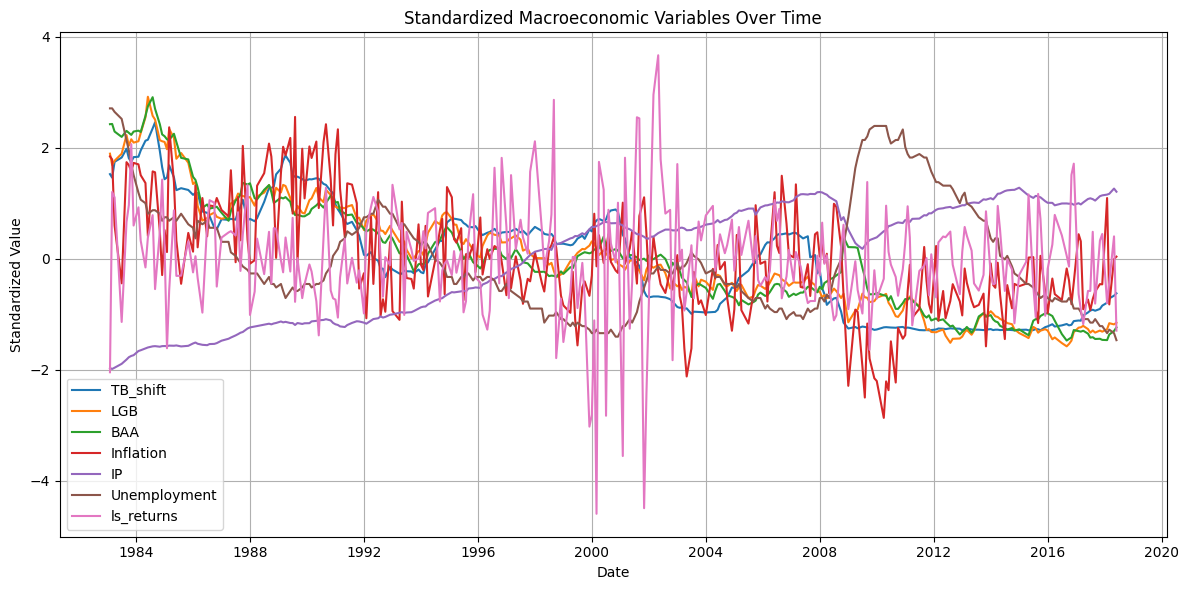

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_standardized_macros(df, figsize=(12, 6), title='Standardized Macroeconomic Variables Over Time'):
    """
    Standardizes each time series (zero mean, unit variance) and plots all on a single time-series plot.

    Parameters
    ----------
    df : pandas.DataFrame
        Contains time-indexed macroeconomic series in columns.
    figsize : tuple of int, optional
        Figure size in inches (width, height).
    title : str, optional
        Title of the plot.
    """
    # Standardize the data
    df_std = (df - df.mean()) / df.std()

    # Plot standardized series
    plt.figure(figsize=figsize)
    for column in df_std.columns:
        plt.plot(df_std.index, df_std[column], label=column)
    plt.xlabel('Date')
    plt.ylabel('Standardized Value')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming `df_macros` is your DataFrame of macroeconomic variables with a DateTimeIndex:
plot_standardized_macros(data)


In [43]:
from statsmodels.tsa.api import VAR

df_std = (data - data.mean()) / data.std()
term_spread = df_std['LGB'] - df_std['BAA']
term_spread.name = 'Term_Spread'
risk_premium = df_std['TB_shift'] - df_std['LGB']
risk_premium.name = 'Risk_Premium'
df_var = pd.concat([df_std['ls_returns'], term_spread, risk_premium ], axis=1, join='inner')
df_var

model = VAR(df_var)
results = model.fit(maxlags=2, ic='aic')
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 07, Aug, 2025
Time:                     09:00:48
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -8.44141
Nobs:                     292.000    HQIC:                  -8.59992
Log likelihood:           49.0617    FPE:                0.000165621
AIC:                     -8.70583    Det(Omega_mle):     0.000154259
--------------------------------------------------------------------
Results for equation ls_returns
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                  -0.000701         0.057447           -0.012           0.990
L1.ls_returns           0.131946         0.059254            2.227           0.026
L1.Term_Spread          0.642183         0.5674

/Users/justusschenk/Bachelorarbeit/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [38]:
df_var.head()

observation_date
1983-01-31 00:00:00   -2.048105
1983-02-28 00:00:00    1.200988
1983-03-31 00:00:00    1.102912
1983-06-30 00:00:00   -1.141602
1983-08-31 00:00:00     0.65891
Name: ls_returns, dtype: object

In [30]:
UTS = data['LGB'] - data['BAA']
df_ts = pd.merge(data['ls_returns', UTS], on="observation_date")
#df_ts.columns = ['ls_returns', 'term_spread']

InvalidIndexError: ('ls_returns', observation_date
1983-01-31   -0.032200
1983-02-28   -0.037400
1983-03-31   -0.032100
1983-06-30   -0.026500
1983-08-31   -0.020800
                ...   
2017-11-30   -0.015871
2018-01-31   -0.014652
2018-02-28   -0.014442
2018-04-30   -0.016576
2018-05-31   -0.017423
Length: 294, dtype: float64)

In [26]:
data['ls_returns']

observation_date
1983-01-31   -0.050787
1983-02-28    0.033292
1983-03-31    0.030754
1983-06-30   -0.027329
1983-08-31    0.019264
                ...   
2017-11-30    0.013697
2018-01-31   -0.018542
2018-02-28   -0.008893
2018-04-30    0.012575
2018-05-31   -0.031393
Name: ls_returns, Length: 294, dtype: float64

In [21]:
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

def analyze_term_structure(df, value_col='ls_returns', term_col='term_spread',
                           break_date='2008-09-30', signif=0.05):
    """
    Analyze the influence of term structure on the value premium with a structural break test (Chow)
    and interaction regression around the Global Financial Crisis (GFC).

    Parameters
    ----------
    df : pd.DataFrame
        Time-indexed DataFrame containing at least two columns: value_col and term_col.
    value_col : str
        Column name for the value premium (e.g., HML).
    term_col : str
        Column name for the term spread.
    break_date : str
        Date string ('YYYY-MM-DD') at which to split pre- and post-GFC.
    signif : float
        Significance level for interpreting Chow test p-value.
    """
    # Ensure proper datetime index
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex")
    
    # Create subsamples
    df_pre = df.loc[:break_date].dropna(subset=[value_col, term_col])
    df_post = df.loc[break_date:].dropna(subset=[value_col, term_col])
    
    # Helper to fit OLS and return SSR & df_resid
    def fit_ssr(data):
        y = data[value_col]
        X = sm.add_constant(data[[term_col]])
        model = sm.OLS(y, X).fit()
        return model.ssr, int(model.df_resid), int(model.df_model) + 1, model
    
    # Fit pre, post, and full samples
    ssr_full, df_full_resid, k, model_full = fit_ssr(df.dropna(subset=[value_col, term_col]))
    ssr_pre, df_pre_resid, _, model_pre = fit_ssr(df_pre)
    ssr_post, df_post_resid, _, model_post = fit_ssr(df_post)
    
    # Chow test statistic
    num = (ssr_full - (ssr_pre + ssr_post)) / k
    den = (ssr_pre + ssr_post) / (df_pre_resid + df_post_resid)
    F_stat = num / den
    p_value = 1 - stats.f.cdf(F_stat, k, df_pre_resid + df_post_resid)
    
    print(f"Chow Test at {break_date}: F = {F_stat:.3f}, p-value = {p_value:.3f}")
    if p_value < signif:
        print(f"→ Reject H0 at α={signif}: significant structural break.\n")
    else:
        print(f"→ Fail to reject H0 at α={signif}: no significant break.\n")
    
    # Interaction regression with post-GFC dummy
    df['post_gfc'] = (df.index > pd.to_datetime(break_date)).astype(int)
    df['term_x_post'] = df[term_col] * df['post_gfc']
    df_int = df.dropna(subset=[value_col, term_col, 'term_x_post'])
    
    X_int = sm.add_constant(df_int[[term_col, 'post_gfc', 'term_x_post']])
    model_int = sm.OLS(df_int[value_col], X_int).fit(cov_type='HAC', cov_kwds={'maxlags':12})
    
    print("Interaction Regression Results:")
    print(model_int.summary())
    
    # Plot term spread vs value premium with regime-colored scatter
    plt.figure(figsize=(8,6))
    plt.scatter(df_pre[term_col], df_pre[value_col], label='Pre-GFC', alpha=0.6)
    plt.scatter(df_post[term_col], df_post[value_col], label='Post-GFC', alpha=0.6)
    plt.xlabel('Term Spread')
    plt.ylabel('Value Premium')
    plt.title('Value Premium vs Term Spread Pre/Post GFC')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return {
        'chow_F': F_stat,
        'chow_p': p_value,
        'model_pre': model_pre,
        'model_post': model_post,
        'model_full': model_full,
        'model_interaction': model_int
    }



# Example usage:
# df_macros should have a DateTimeIndex and columns: 'value_premium', 'term_spread'
results = analyze_term_structure(df_ts)


InvalidIndexError: ('ls_returns', observation_date
1983-01-31    0.027200
1983-02-28    0.023900
1983-03-31    0.017700
1983-06-30    0.018700
1983-08-31    0.022600
                ...   
2017-11-30    0.014129
2018-01-31    0.013748
2018-02-28    0.014258
2018-04-30    0.012324
2018-05-31    0.011877
Length: 294, dtype: float64)

In [28]:
df_ts

NameError: name 'df_ts' is not defined